In [1]:
import sbi
from dmri.simulators.models import MultiShellBall3StickSharedDiffusivity
#from dmri.simulators.models import MultiShellBall3StickSharedDiffusivity
sim_type = MultiShellBall3StickSharedDiffusivity

ERROR:2026-03-25 14:52:18,640:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 150, in _check_cuda_versions
    assert cuda_versions is not None
           ^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError
ERROR:2026-03-25 14:52:18,644:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda13.initialize()
Traceback (most recent call last):
  File "/home

In [2]:
from dmri.simulators.acquisition_scheme import acquisition_scheme, random_hcp_acquisition, random_hcp_large_acquisition
import jax
import jax.numpy as jnp

@jax.jit
def simulator(rng, mask_prior_hyperparameter=None):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_acquisition(rng0)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))

    model_mask = jnp.ones((5,), dtype=bool)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    data = {"acq": acq, "model_mask": model_mask, "prior_mask": jnp.ones((1,)), "theta": theta, "x": x_o}
    return data

@jax.jit
def simulator2(rng, mask_prior_hyperparameter=None):
    rng0, rng1, rng2, rng3, rng4, rng5 = jax.random.split(rng, 6)
    acq = random_hcp_large_acquisition(rng0, num_acquisitions=297, typical_prob=0.8, random_prob=0.2)


    theta = jax.random.normal(rng1, shape=(sim_type.theta_dim,))

    model_mask = jnp.ones((5,), dtype=bool)
    ball_stick = sim_type.from_theta(theta, model_mask=model_mask)

    x_o = ball_stick.signal(acq, rng=rng5)
    data = {"acq": acq, "model_mask": model_mask, "prior_mask": jnp.ones((1,)), "theta": theta, "x": x_o}
    return data


In [3]:
simulator2(jax.random.PRNGKey(0))

{'acq': acquisition_scheme(bvals=Array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.,
        1000., 2000., 2000., 2000., 2000., 20

In [4]:
data = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=50))

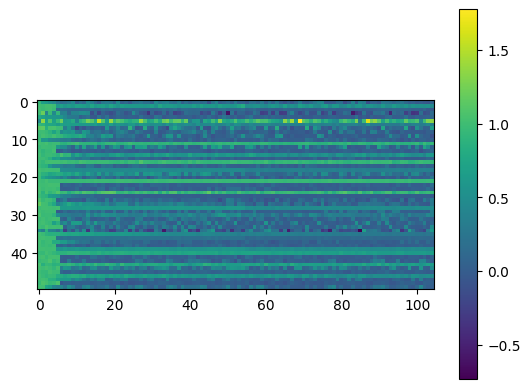

In [5]:
import matplotlib.pyplot as plt
plt.imshow(data["x"])

plt.colorbar()

In [6]:
from dmri.train.dataset import SimulationDataset
from torch.utils.data import DataLoader

dataset = SimulationDataset(simulator, rng=jax.random.PRNGKey(1), simulation_device=jax.devices("cpu")[0], simulation_batch_size=4096, buffer_size=1_000_000, return_numpy=True)
dataset2 = SimulationDataset(simulator2, rng=jax.random.PRNGKey(1), simulation_device=jax.devices("cpu")[0], simulation_batch_size=4096, buffer_size=1_000_000, return_numpy=True)

/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignme

In [7]:
import torch
torch.cuda.is_available()

True

In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class TorchReadySimulationDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        sample = dict(self.base_dataset[index])
        acq = sample["acq"]
        sample["acq"] = {
            "bvals": np.asarray(acq.bvals),
            "bvecs": np.asarray(acq.bvecs),
        }
        for key, value in sample.items():
            if key == "acq":
                continue
            sample[key] = np.asarray(value)
        return sample


def to_device(batch, device):
    if isinstance(batch, dict):
        return {k: to_device(v, device) for k, v in batch.items()}
    if torch.is_tensor(batch):
        return batch.to(device, non_blocking=True)
    return batch


class CUDAPrefetcher:
    def __init__(self, loader, device):
        self.loader = loader
        self.device = device
        self.stream = (
            torch.cuda.Stream(device=device) if device.type == "cuda" else None
        )

    def __iter__(self):
        if self.stream is None:
            for batch in self.loader:
                yield batch
            return

        loader_iter = iter(self.loader)
        next_batch = None

        def preload():
            nonlocal next_batch
            try:
                batch = next(loader_iter)
            except StopIteration:
                next_batch = None
                return
            with torch.cuda.stream(self.stream):
                next_batch = to_device(batch, self.device)

        preload()
        while next_batch is not None:
            torch.cuda.current_stream(self.device).wait_stream(self.stream)
            batch = next_batch
            preload()
            yield batch

torch_dataset = TorchReadySimulationDataset(dataset)
dataloader = DataLoader(
    torch_dataset,
    batch_size=2048,
    shuffle=True,
    pin_memory=device.type == "cuda",
    num_workers=0,
)
dataloader2 = DataLoader(
    TorchReadySimulationDataset(dataset2),
    batch_size=2048,
    shuffle=True,
    pin_memory=device.type == "cuda",
    num_workers=0,
)

prefetch_dataloader = CUDAPrefetcher(dataloader, device)
prefetch_dataloader2 = CUDAPrefetcher(dataloader2, device)

In [9]:
from sbi_embedding_net import SBIEmbeddingNet

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net_embed = SBIEmbeddingNet(model_dim=128,output_dim=512,num_cls_tokens=4,num_layers=4).to(device)

In [11]:
import time
import torch
from torch_sbi_baseline import build_nsf

def split_batch(batch):
    theta = batch["theta"].float()
    condition = {
        "x": batch["x"].float(),
        "acq": {
            "bvals": batch["acq"]["bvals"].float(),
            "bvecs": batch["acq"]["bvecs"].float(),
        },
    }
    return theta, condition

def slice_batch(batch, stop):
    if torch.is_tensor(batch):
        return batch[:stop]
    return {key: slice_batch(value, stop) for key, value in batch.items()}

first_batch = next(iter(prefetch_dataloader))
init_theta, init_condition = split_batch(first_batch)

flow = build_nsf(
    batch_x=init_theta,
    batch_y=init_condition,
    embedding_net=net_embed,
    z_score_y="none",
    hidden_features=256,
    num_transforms=8,
).to(device)
optimizer = torch.optim.AdamW(flow.parameters(), lr=3e-4, weight_decay=1e-5)

flow.loss(init_theta, init_condition).mean()

tensor(19.3246, device='cuda:0', grad_fn=<MeanBackward0>)

In [12]:
total_params = sum(p.numel() for p in flow.parameters())
total_params

7217104

In [13]:

def total_loss(flow, batch1, batch2):
    loss1 = flow.loss(*split_batch(batch1)).mean()
    loss2 = flow.loss(*split_batch(batch2)).mean()
    return (loss1 + loss2) / 2

In [14]:
max_steps = 1000
log_every = 5
grad_clip_norm = 5.0
loss_history = []

flow.train()
start_time = time.perf_counter()
iter1 = iter(prefetch_dataloader)
iter2 = iter(prefetch_dataloader2)

for step in range(max_steps):
    optimizer.zero_grad(set_to_none=True)
    batches = [next(iter1), next(iter2)]
    loss = total_loss(flow, *batches)
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(flow.parameters(), grad_clip_norm)
    optimizer.step()

    loss_value = float(loss.detach().cpu())
    loss_history.append(loss_value)

    if step % log_every == 0:
        elapsed = time.perf_counter() - start_time
        mean_loss = sum(loss_history[-log_every:]) / len(loss_history[-log_every:])
        print(
            f"step={step:04d} "
            f"loss={loss_value:.4f} "
            f"avg_last_{log_every}={mean_loss:.4f} "
            f"grad_norm={float(grad_norm):.2f} "
        )

    if step >= max_steps:
        break


step=0000 loss=19.3430 avg_last_5=19.3430 grad_norm=7.83 
step=0005 loss=17.1826 avg_last_5=17.4368 grad_norm=2.06 
step=0010 loss=17.0793 avg_last_5=17.0761 grad_norm=1.47 
step=0015 loss=16.9248 avg_last_5=16.9714 grad_norm=1.59 
step=0020 loss=16.6106 avg_last_5=16.6969 grad_norm=3.15 
step=0025 loss=16.3622 avg_last_5=16.5251 grad_norm=3.38 
step=0030 loss=16.3546 avg_last_5=16.3641 grad_norm=5.96 
step=0035 loss=16.2462 avg_last_5=16.2623 grad_norm=9.22 
step=0040 loss=16.1410 avg_last_5=16.1897 grad_norm=11.93 
step=0045 loss=16.1991 avg_last_5=16.1424 grad_norm=23.93 
step=0050 loss=16.0672 avg_last_5=16.1084 grad_norm=21.61 
step=0055 loss=16.4854 avg_last_5=16.2925 grad_norm=46.50 
step=0060 loss=16.9352 avg_last_5=16.5613 grad_norm=60.32 
step=0065 loss=16.0282 avg_last_5=16.2053 grad_norm=23.63 
step=0070 loss=16.0447 avg_last_5=16.1835 grad_norm=22.87 
step=0075 loss=16.2300 avg_last_5=16.0704 grad_norm=42.79 
step=0080 loss=16.0532 avg_last_5=15.9475 grad_norm=25.66 
step=

StopIteration: 

In [ ]:
flow.eval()
with torch.no_grad():
    eval_batch = slice_batch(next(iter(prefetch_dataloader)), 256)
    eval_theta, eval_condition = split_batch(eval_batch)
    eval_loss = flow.loss(eval_theta, eval_condition).mean()
    samples, log_probs = flow.sample_and_log_prob(torch.Size([4]), eval_condition)

eval_loss.item(), samples.shape, log_probs.shape

/home/macke/mgloeckler90/miniconda3/envs/new_dmri/lib/python3.12/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2259.)
  outputs, _ = torch.triangular_solve(


(16.7520809173584, torch.Size([4, 256, 12]), torch.Size([4, 256]))